# <font color = Green> ***Linear Regression Assignment***

----------

    Author: Lakshmi Sagar SP
    Reg. Email: lakshmisagar82@gmail.com

------

## <font color = Dark> *I. Objective*

    The main objective is to identify strong factors that affect the demand for shared bikes in the American Market post-lockdown and model it so that the client, 'BOOMBIKES' can build a strategic business plan around it to meet the demands of customers, helping them increase their revenues in a post-pandemic era.

## <font color = Dark> *II. Data*

    1. 'day.csv': Contains Meteorological data from 2018 and 2019, date attributes and people's styles along with the number of bikes that were rented on each day.
    
    2. Data Dictionary: Contains a description of all the columns in 'day.csv'

--------

## <font color = Dark> *III. Data Understanding, Cleaning and Manipulation*

In [11]:
# importing all the necessary libraries and warnings

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

In [12]:
# Reading the data
bike_data = pd.read_csv("day.csv")

In [13]:
# TO get a look at the data like shape, and missing values, summary statistics, to get a feel for the data, etc.

def datalook(df):
    pd.set_option("display.max_columns", None)
    print("\nDataset Info\n")
    print(df.info())
    print("\n\n Summary Statistics\n")
    print(df.describe())
    print("\n")
    print("\nFirst and last 5 rows with all columns\n")
    return df

In [14]:
datalook(bike_data)


Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB
None


 Summary Statistics

          instant      season          yr        m

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,5,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,6,0,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,0,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,1,1,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


#### <font color = Dark> *Insight*

    > There are no missing values in the data
    
    > There are 730 entries in the data which is data for each day of 2 years (2018-2019)
    
    > Based on the summary statistics, the data does not seem to have any wild outliers.

In [17]:
# Duplicates check

In [18]:
bike_data_copy = bike_data
bike_data_copy.drop_duplicates(subset = None, inplace = True)
bike_data_copy.shape

(730, 16)

In [19]:
# So there are no duplicate values in the data set

#### <font color = Dark> *Approach*

    > Since the 'instant' column tells us the record no. or the day no. and we already have temporal features available to give larger business insight, we can drop the instant column and reset the index to start from 1.
    
    > Since the 'dteday' column also serves the same purpose and we have seen that there are no wild outliers as per the summary statistics, we can drop this one as well as most of the contextual info can be got from the temporal features derived from the date.

In [22]:
 # Dropping the instant and date column

In [23]:
bike_data.drop(columns = ["instant","dteday"], axis = 1, inplace = True)

In [24]:
bike_data.index = bike_data.index + 1

In [25]:
bike_data

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
2,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
3,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
4,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
5,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,5,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
727,1,1,12,0,6,0,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
728,1,1,12,0,0,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
729,1,1,12,0,1,1,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


#### <font color = Dark> *Exploring "Casual" and "Registered" Columns*

    > Both "Casual" and "Registered" columns are derived from the target variable so there will be collinearity.
    
    > So it makes sense to drop them but it also makes business sense to understand how your causal and registered users are behaving as the company may have already spent marketing dollars in acquiring the registered users.

    > If registered and casual users can add predictive power in terms of a ratio to the model, like relationship with other variables like holiday, weekday, etc., it makes sense to keep them without introducing collinearity or redundancy.

    > We can remove them if they do not give much insight when compared with other categorical variables.

In [29]:
# Let's get a difference between casual and registered users
bike_data["cas_reg_diff"] = bike_data["casual"] - bike_data["registered"]

# As seen in the data, casual users seem less than registered so checking the number of occurrences where casual users are more. 
bike_data[bike_data_copy["cas_reg_diff"] > 0].shape

(3, 15)

    > Only 3 entries out of 730 have casual more than registered so this cannot add any predictive power to the model even as a ratio when compared to other variables. 

    > So, let's drop these columns too!

In [32]:
# Dropping "casual" and "registered"
bike_data.drop(columns = ["casual","registered","cas_reg_diff"], axis = 1, inplace = True)

#### <font color = Dark> *Exploring Categorical Columns*

In [34]:
bike_data.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [35]:
# Renaming a few columns so they're easier to understand

bike_data.rename(columns={"yr": "year", "mnth": "month", "hum": "humidity", "cnt": "bikes"}, inplace = True)

In [36]:
# Some of these categorical columns have been encoded
# Convert these columns to categorical by replacing them with strings and creating dummy ones later.

In [37]:
# season
bike_data["season"].replace({1:"spring", 2:"summer", 3:"fall", 4:"winter"}, inplace = True)

# month
bike_data["month"].replace({1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"june", 7:"july",
                            8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"}, inplace = True)

# weekday
bike_data["weekday"].replace({0:"sun",1:"mon",2:"tue",3:"wed",
                              4:"thu",5:"fri",6:"sat"}, inplace = True)

In [38]:
# Since we cannot categorically represent all the words describing the "weathersit" column,
# we can encompass them within 1 word that best describes each weather situation

# 1: Clear
# 2: Cloudy or Misty
# 3: Drizzle
# 4: Stormy

In [39]:
bike_data["weathersit"].replace({1:"Clear", 2:"Cloudy", 3:"Drizzle", 4:"Stormy"}, inplace = True)

In [40]:
bike_data

,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,bikes
1,spring,0,jan,0,mon,1,Cloudy,14.110847,18.18125,80.5833,10.749882,985
2,spring,0,jan,0,tue,1,Cloudy,14.902598,17.68695,69.6087,16.652113,801
3,spring,0,jan,0,wed,1,Clear,8.050924,9.47025,43.7273,16.636703,1349
4,spring,0,jan,0,thu,1,Clear,8.200000,10.60610,59.0435,10.739832,1562
5,spring,0,jan,0,fri,1,Clear,9.305237,11.46350,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...,...
726,spring,1,dec,0,fri,1,Cloudy,10.420847,11.33210,65.2917,23.458911,2114
727,spring,1,dec,0,sat,0,Cloudy,10.386653,12.75230,59.0000,10.416557,3095
728,spring,1,dec,0,sun,0,Cloudy,10.386653,12.12000,75.2917,8.333661,1341
729,spring,1,dec,0,mon,1,Clear,10.489153,11.58500,48.3333,23.500518,1796


In [41]:
# Seperating numerical and categorical variables for easy callablity

In [42]:
num_vars = ["temp", "atemp", "humidity", "windspeed", "bikes"]
cat_vars = bike_data.columns[~bike_data.columns.isin(num_vars)]

#### <font color = Dark> *Let's Visualise the data using scatter and box plots*

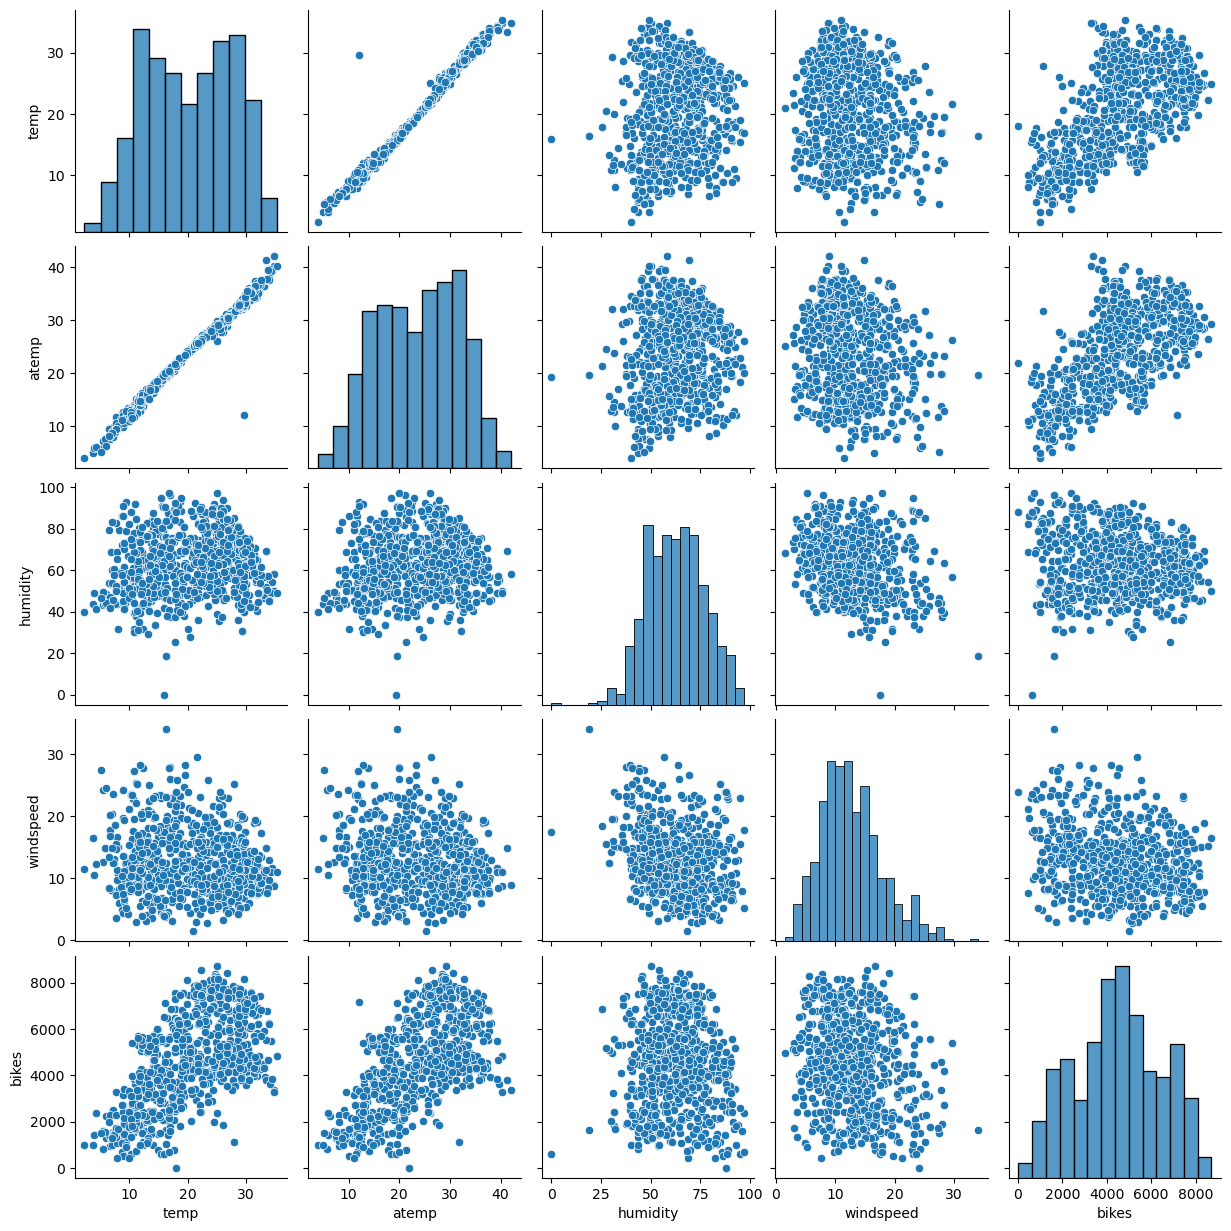

In [44]:
sns.pairplot(bike_data[num_vars])
plt.show()

#### <font color = Dark> *Insight*

    > There seems to be collinearity between temp and atemp which is expected to some extent
    
    > There is a decent linear relationship between 'temp', 'atemp', 'humidity' and 'bikes', the target variable

In [48]:
# Box plots to visualise the categorical variables

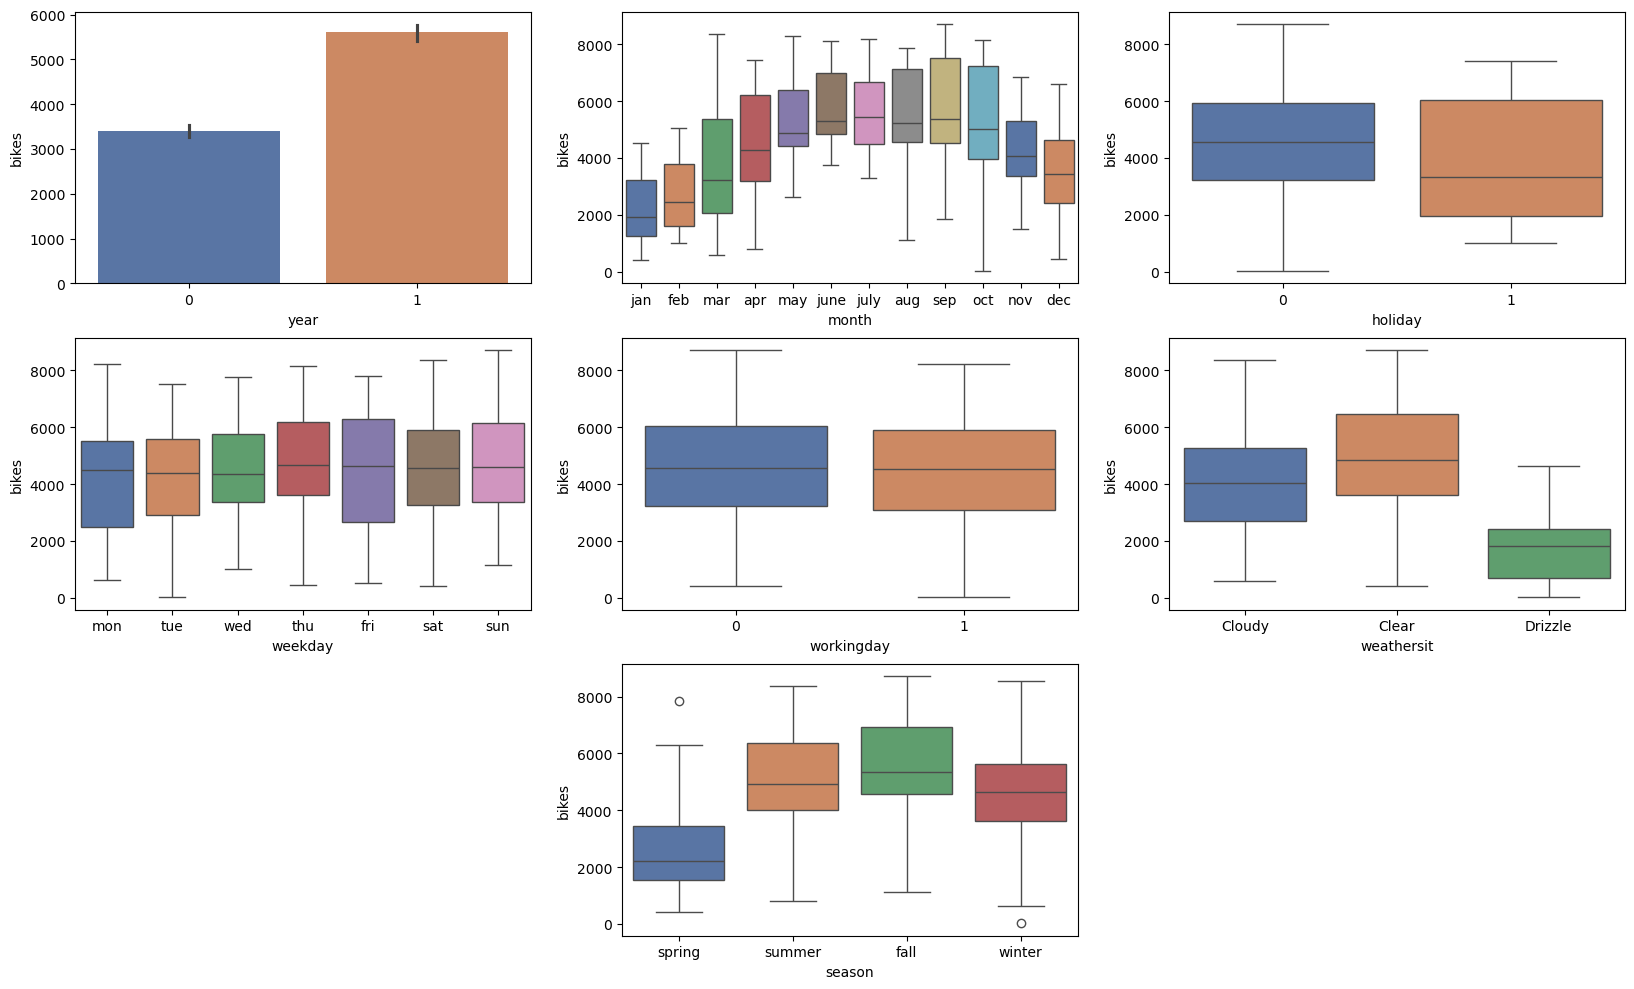

In [49]:
plt.figure(figsize = (20,12))

plt.subplot(3,3,1)
sns.barplot(x = "year", y = "bikes", data = bike_data, palette = "deep")

plt.subplot(3,3,2)
sns.boxplot(x = "month", y = "bikes", data = bike_data, palette = "deep")

plt.subplot(3,3,3)
sns.boxplot(x = "holiday", y = "bikes", data = bike_data, palette = "deep")

plt.subplot(3,3,4)
sns.boxplot(x = "weekday", y = "bikes", data = bike_data, palette = "deep")

plt.subplot(3,3,5)
sns.boxplot(x = "workingday", y = "bikes", data = bike_data, palette = "deep")

plt.subplot(3,3,6)
sns.boxplot(x = "weathersit", y = "bikes", data = bike_data, palette = "deep")

plt.subplot(3,3,8)
sns.boxplot(x = "season", y = "bikes", data = bike_data, palette = "deep")

plt.show()

#### <font color = Dark> *Insight*

    > There is a significant increase in the overall demand for shared bikes from 2018 to 2019.
    
    > The "Spring" and "Winter" months like January, February, March and December have a lower need for shared bikes. Some of these months  fall into the holiday season in America which may explain the dip in demand.
    
    > Non-holidays have a higher median compared to holidays. 
    
    > There is not much fluctuation between the days of the week.
    
    > Clear weather is the best situation for BoomBikes as the demand seems to peak in such weather.

    > With this we get an idea that month, year, season, weathersit, and holiday may be good predictors of the demand for bikes along with numerical variables like temp and humidity.
    

## <font color = Dark> *IV. Data Preperation*

#### <font color = Dark> *Creating Dummy Variables*

In [56]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 1 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    object 
 1   year        730 non-null    int64  
 2   month       730 non-null    object 
 3   holiday     730 non-null    int64  
 4   weekday     730 non-null    object 
 5   workingday  730 non-null    int64  
 6   weathersit  730 non-null    object 
 7   temp        730 non-null    float64
 8   atemp       730 non-null    float64
 9   humidity    730 non-null    float64
 10  windspeed   730 non-null    float64
 11  bikes       730 non-null    int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 68.6+ KB


In [57]:
month_dum = pd.get_dummies(bike_data.month, drop_first = True)
month_dum = month_dum.astype(int)

season_dum = pd.get_dummies(bike_data.season, drop_first = True)
season_dum = season_dum.astype(int)

weekday_dum = pd.get_dummies(bike_data.weekday, drop_first = True)
weekday_dum = weekday_dum.astype(int)

weather_dum = pd.get_dummies(bike_data.weathersit, drop_first = True)
weather_dum = weather_dum.astype(int)

In [58]:
bike_new = pd.concat([bike_data, season_dum, month_dum, weekday_dum, weather_dum], axis = 1)

In [59]:
# Since we have created the dummy variables with encoding, let's drop the categorical variables

bike_new.drop(["month", "season", "weekday", "weathersit"], axis = 1, inplace = True)

In [60]:
bike_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 1 to 730
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        730 non-null    int64  
 1   holiday     730 non-null    int64  
 2   workingday  730 non-null    int64  
 3   temp        730 non-null    float64
 4   atemp       730 non-null    float64
 5   humidity    730 non-null    float64
 6   windspeed   730 non-null    float64
 7   bikes       730 non-null    int64  
 8   spring      730 non-null    int64  
 9   summer      730 non-null    int64  
 10  winter      730 non-null    int64  
 11  aug         730 non-null    int64  
 12  dec         730 non-null    int64  
 13  feb         730 non-null    int64  
 14  jan         730 non-null    int64  
 15  july        730 non-null    int64  
 16  june        730 non-null    int64  
 17  mar         730 non-null    int64  
 18  may         730 non-null    int64  
 19  nov         730 non-null    i

In [61]:
bike_new.head()

,year,holiday,workingday,temp,atemp,humidity,windspeed,bikes,spring,summer,winter,aug,dec,feb,jan,july,june,mar,may,nov,oct,sep,mon,sat,sun,thu,tue,wed,Cloudy,Drizzle
1,0,0,1,14.110847,18.18125,80.5833,10.749882,985,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
2,0,0,1,14.902598,17.68695,69.6087,16.652113,801,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
3,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
5,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### <font color = Dark> *Splitting the data to Train and test*

In [64]:
np.random.seed(0)
bike_train, bike_test = train_test_split(bike_new, train_size = 0.7, random_state = 100)
print(bike_train.shape)
print(bike_test.shape)

(510, 30)
(220, 30)


#### <font color = Dark> *Scaling*

In [67]:
scaler = MinMaxScaler()
numerical_variables = ["temp", "atemp", "humidity", "windspeed", "bikes"]
bike_train[numerical_variables] = scaler.fit_transform(bike_train[numerical_variables])

In [68]:
bike_train.head()

,year,holiday,workingday,temp,atemp,humidity,windspeed,bikes,spring,summer,winter,aug,dec,feb,jan,july,june,mar,may,nov,oct,sep,mon,sat,sun,thu,tue,wed,Cloudy,Drizzle
577,1,0,1,0.815169,0.766351,0.725633,0.264686,0.827658,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
427,1,0,0,0.442393,0.438975,0.640189,0.255342,0.465255,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
729,1,0,1,0.245101,0.200348,0.498067,0.663106,0.204096,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
483,1,0,0,0.395666,0.391735,0.504508,0.188475,0.482973,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
112,0,0,0,0.345824,0.318819,0.751824,0.380981,0.191095,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [69]:
bike_train.describe()

,year,holiday,workingday,temp,atemp,humidity,windspeed,bikes,spring,summer,winter,aug,dec,feb,jan,july,june,mar,may,nov,oct,sep,mon,sat,sun,thu,tue,wed,Cloudy,Drizzle
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.507843,0.025490,0.711765,0.537440,0.513156,0.650480,0.320883,0.513499,0.243137,0.247059,0.247059,0.096078,0.084314,0.066667,0.088235,0.076471,0.076471,0.098039,0.084314,0.086275,0.084314,0.080392,0.154902,0.129412,0.137255,0.143137,0.152941,0.135294,0.345098,0.029412
std,0.500429,0.157763,0.453386,0.225858,0.212410,0.145846,0.169803,0.224421,0.429398,0.431725,0.431725,0.294988,0.278131,0.249689,0.283915,0.266010,0.266010,0.297660,0.278131,0.281045,0.278131,0.272166,0.362166,0.335985,0.344454,0.350557,0.360284,0.342373,0.475867,0.169124
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.339853,0.332086,0.538643,0.199179,0.356420,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.542596,0.529718,0.653714,0.296763,0.518638,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.735215,0.688457,0.754830,0.414447,0.684710,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [70]:
# All the variables have been scaled and are between 0 and 1

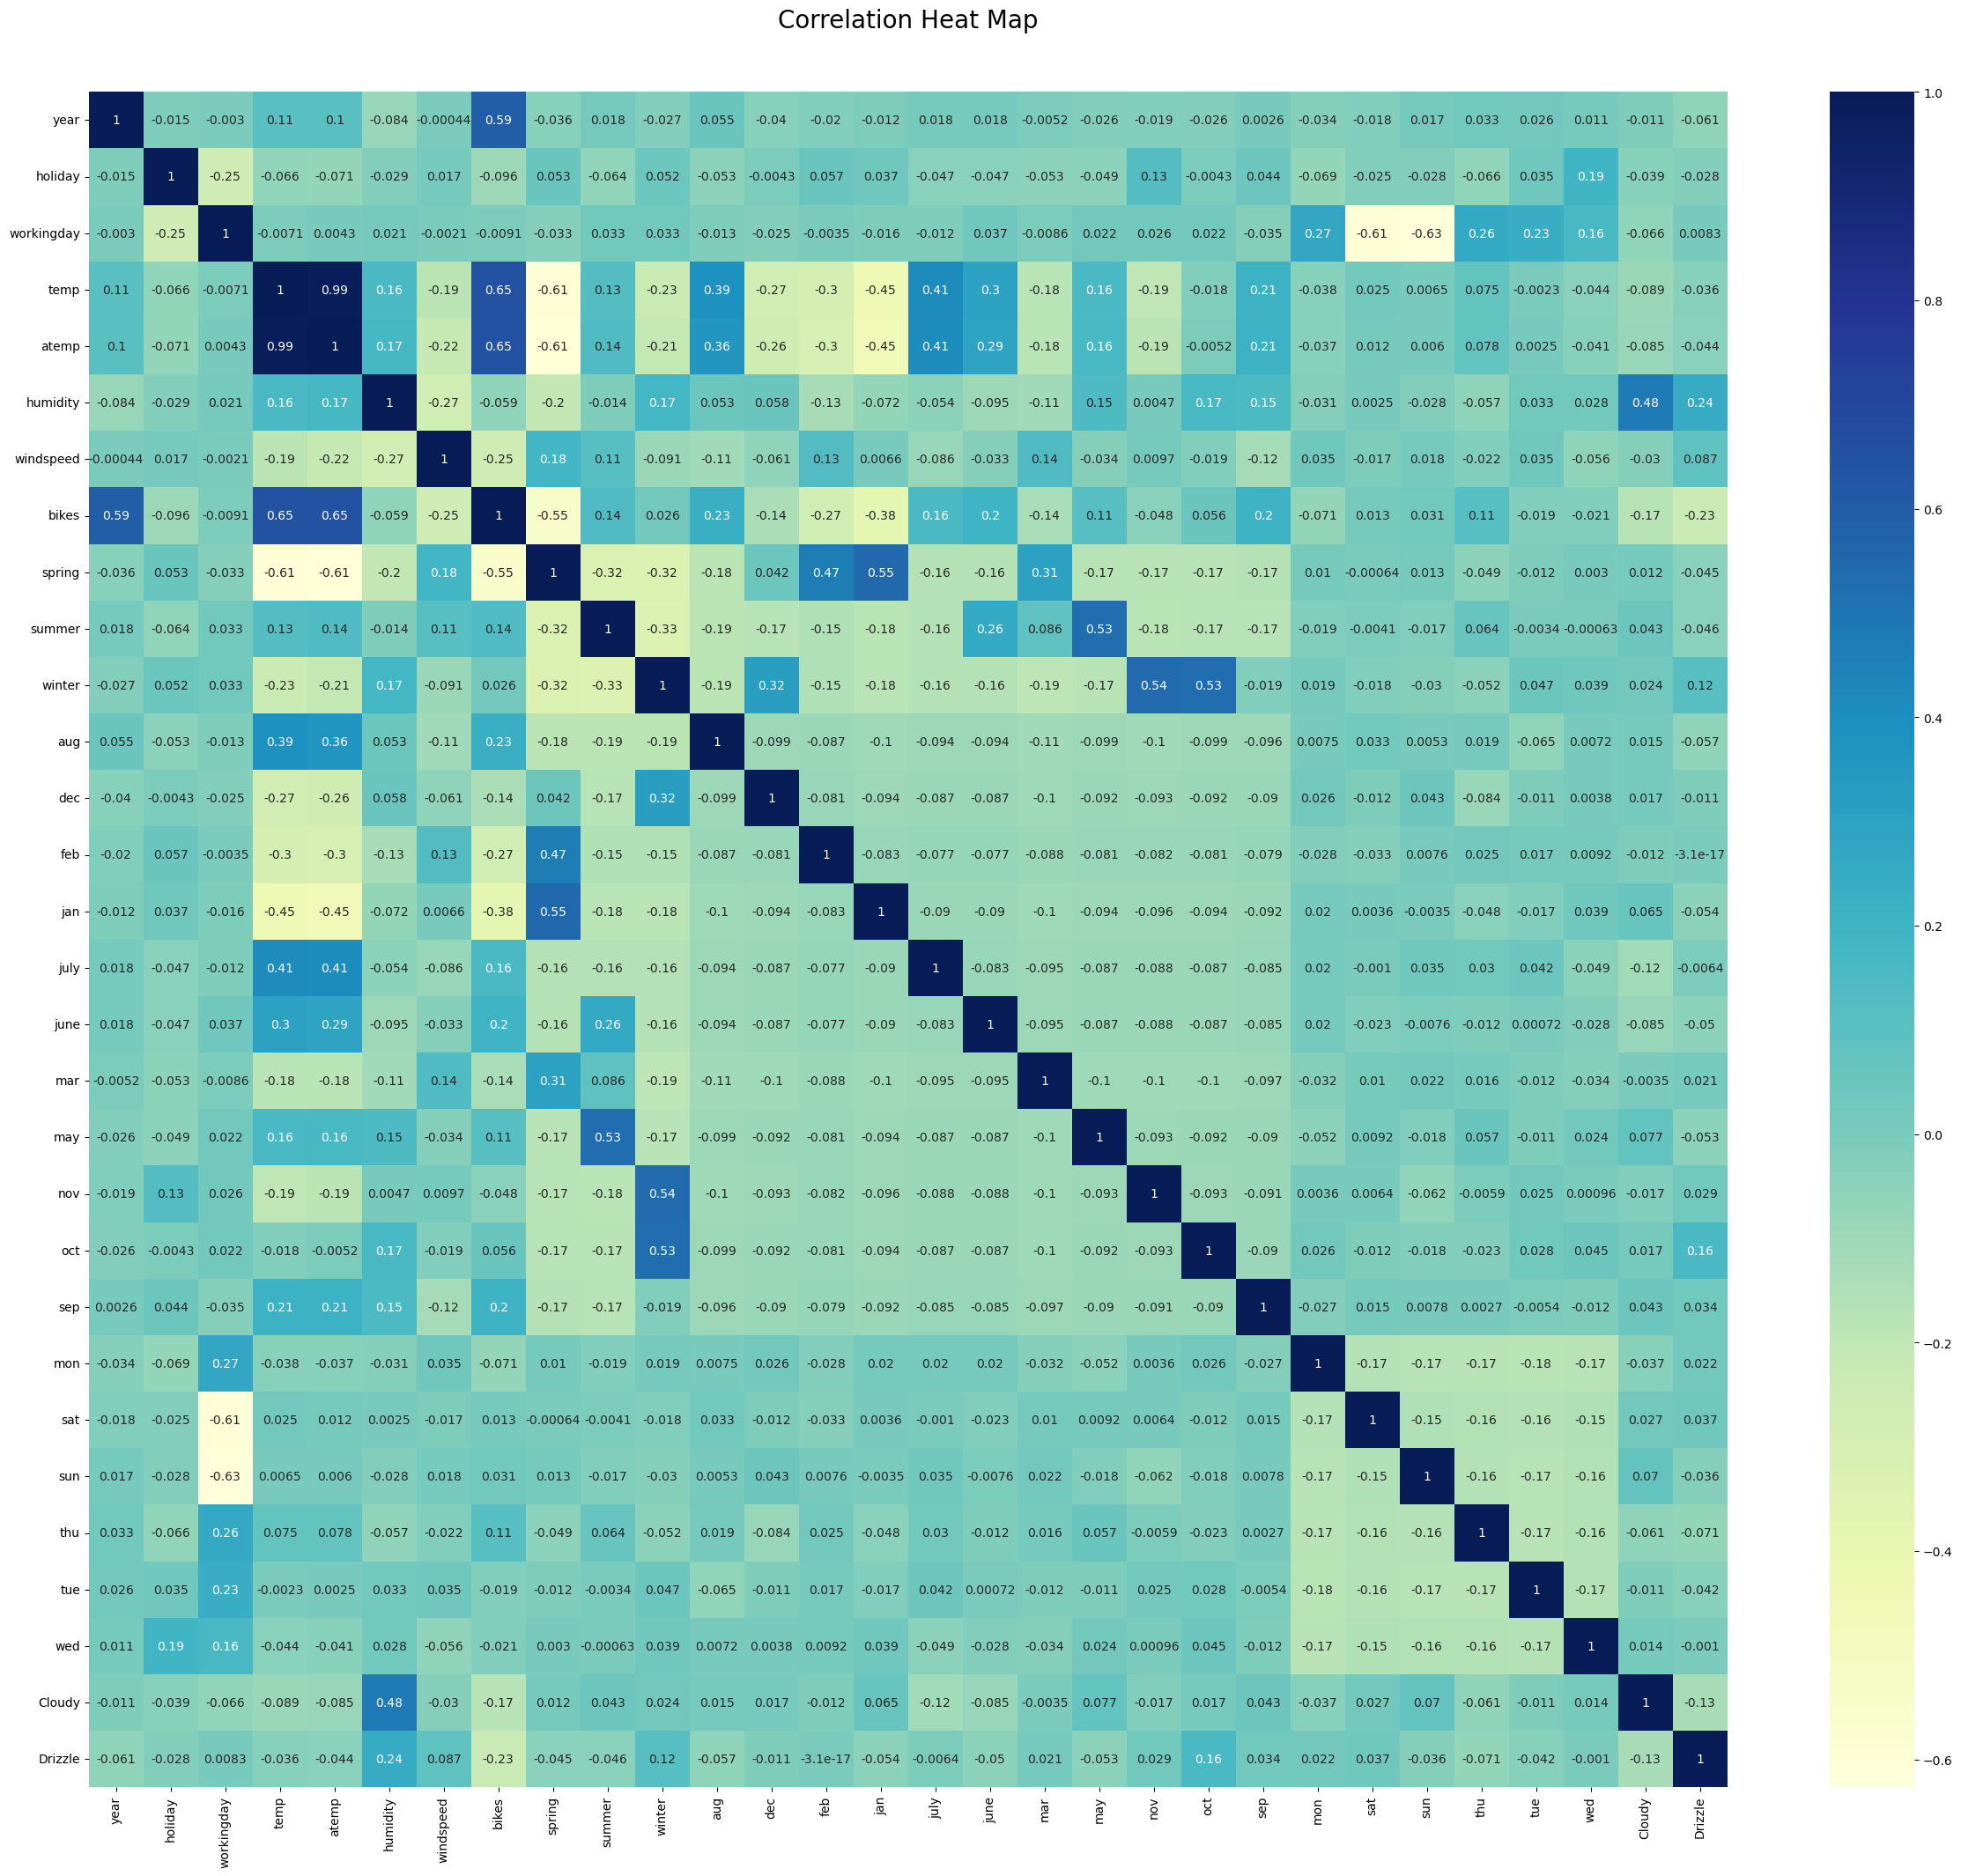

In [71]:
# Let's check the correlation between the variables

plt.figure(figsize = (30,25))
sns.heatmap(data = bike_train.corr(), annot = True, cmap = "YlGnBu")
plt.title("Correlation Heat Map\n\n",fontdict={"fontsize": 20, "fontweight": 20, "color": "Black"})
plt.show()

#### <font color = Dark> *Insight*

    > "bikes" has a good correlation with "temp", "year" and "humidity"
    
    > There is a lot of collinearity between multiple variables seen like winter with oct and nov, cloudy with humidity, etc.

## <font color = Dark> *V. Building the model*

In [77]:
# Using RFE to pick the initial 15 variables out of 30

In [78]:
y_train = bike_train.pop("bikes")
X_train = bike_train

In [79]:
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, n_features_to_select=15)
rfe = rfe.fit(X_train, y_train)

In [80]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('year', True, 1),
 ('holiday', True, 1),
 ('workingday', False, 4),
 ('temp', True, 1),
 ('atemp', False, 3),
 ('humidity', True, 1),
 ('windspeed', True, 1),
 ('spring', True, 1),
 ('summer', True, 1),
 ('winter', True, 1),
 ('aug', False, 10),
 ('dec', True, 1),
 ('feb', False, 2),
 ('jan', True, 1),
 ('july', True, 1),
 ('june', False, 12),
 ('mar', False, 15),
 ('may', False, 9),
 ('nov', True, 1),
 ('oct', False, 13),
 ('sep', True, 1),
 ('mon', False, 8),
 ('sat', False, 5),
 ('sun', False, 6),
 ('thu', False, 14),
 ('tue', False, 7),
 ('wed', False, 11),
 ('Cloudy', True, 1),
 ('Drizzle', True, 1)]

In [81]:
col = X_train.columns[rfe.support_]
print(col)

Index(['year', 'holiday', 'temp', 'humidity', 'windspeed', 'spring', 'summer',
       'winter', 'dec', 'jan', 'july', 'nov', 'sep', 'Cloudy', 'Drizzle'],
      dtype='object')


In [82]:
X_train.columns[~rfe.support_]

Index(['workingday', 'atemp', 'aug', 'feb', 'june', 'mar', 'may', 'oct', 'mon',
       'sat', 'sun', 'thu', 'tue', 'wed'],
      dtype='object')

In [83]:
X_train_rfe = X_train[col]

In [84]:
# Building the 1st model using the RFE picked variables

In [85]:
X_train_mod_1 = sm.add_constant(X_train_rfe)
model_1 = sm.OLS(y_train, X_train_mod_1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  bikes   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     179.4
Date:                Fri, 21 Feb 2025   Prob (F-statistic):          8.15e-189
Time:                        21:33:29   Log-Likelihood:                 514.19
No. Observations:                 510   AIC:                            -996.4
Df Residuals:                     494   BIC:                            -928.6
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3197      0.036      8.859      0.0

In [86]:
# defining a general VIF calculator function
def VIF_Calculator(df):
    vif = pd.DataFrame()
    X = df
    vif["Features"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif["VIF"] = round(vif["VIF"],2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    return vif

In [87]:
VIF_Calculator(X_train_rfe)

,Features,VIF
3,humidity,30.89
2,temp,17.79
4,windspeed,4.72
5,spring,4.37
7,winter,4.06
6,summer,2.82
13,Cloudy,2.32
0,year,2.09
11,nov,1.85
9,jan,1.75


In [88]:
# Humidity has very high VIF
# Dec and Nov have high p-values

In [89]:
# Dropping humidity to check changes in p-values
X_train_rfe = X_train_rfe.drop(["humidity"], axis = 1)

In [90]:
# Building 2nd model with humidity dropped

In [91]:
X_train_mod_2 = sm.add_constant(X_train_rfe)
model_2 = sm.OLS(y_train, X_train_mod_2).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  bikes   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     184.5
Date:                Fri, 21 Feb 2025   Prob (F-statistic):          4.75e-186
Time:                        21:33:30   Log-Likelihood:                 504.85
No. Observations:                 510   AIC:                            -979.7
Df Residuals:                     495   BIC:                            -916.2
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2450      0.032      7.618      0.0

In [92]:
# Checking VIF

In [93]:
VIF_Calculator(X_train_rfe)

,Features,VIF
2,temp,5.17
3,windspeed,4.67
6,winter,2.95
4,spring,2.89
5,summer,2.24
0,year,2.07
10,nov,1.81
8,jan,1.66
9,july,1.59
12,Cloudy,1.57


In [94]:
# The VIF values for temp have dropped drastically along with the p-value for Dec as well
# Let's improve the model further
# Dropping nov for having high p-value

In [95]:
X_train_rfe = X_train_rfe.drop(["nov"], axis = 1)

In [96]:
# Building 3rd model with nov also dropped

In [97]:
X_train_mod_3 = sm.add_constant(X_train_rfe)
model_3 = sm.OLS(y_train, X_train_mod_3).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  bikes   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     197.0
Date:                Fri, 21 Feb 2025   Prob (F-statistic):          2.74e-186
Time:                        21:33:30   Log-Likelihood:                 502.67
No. Observations:                 510   AIC:                            -977.3
Df Residuals:                     496   BIC:                            -918.1
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2283      0.031      7.310      0.0

In [98]:
# VIF Check
VIF_Calculator(X_train_rfe)

,Features,VIF
2,temp,5.14
3,windspeed,4.62
4,spring,2.89
5,summer,2.24
0,year,2.07
6,winter,2.05
8,jan,1.65
9,july,1.59
11,Cloudy,1.57
10,sep,1.34


In [99]:
# The VIF values have not changed drastically by dropping nov, however, dec column is now insignificant
# Dropping Dec for high p-value

In [100]:
X_train_rfe = X_train_rfe.drop(["dec"], axis = 1)

In [101]:
# Building 4th model with nov also dropped

In [102]:
X_train_mod_4 = sm.add_constant(X_train_rfe)
model_4 = sm.OLS(y_train, X_train_mod_4).fit()
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  bikes   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     212.3
Date:                Fri, 21 Feb 2025   Prob (F-statistic):          8.14e-187
Time:                        21:33:30   Log-Likelihood:                 501.13
No. Observations:                 510   AIC:                            -976.3
Df Residuals:                     497   BIC:                            -921.2
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2154      0.030      7.088      0.0

In [103]:
# VIF Check
VIF_Calculator(X_train_rfe)

,Features,VIF
2,temp,5.13
3,windspeed,4.62
4,spring,2.75
5,summer,2.24
0,year,2.07
6,winter,1.78
7,jan,1.61
8,july,1.59
10,Cloudy,1.56
9,sep,1.34


In [104]:
# Not much change in VIF. Dropping Jan for high p-values

In [105]:
X_train_rfe = X_train_rfe.drop(["jan"], axis = 1)

In [106]:
# Building 5th model with jan also dropped

In [107]:
X_train_mod_5 = sm.add_constant(X_train_rfe)
model_5 = sm.OLS(y_train, X_train_mod_5).fit()
print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:                  bikes   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     229.6
Date:                Fri, 21 Feb 2025   Prob (F-statistic):          5.06e-187
Time:                        21:33:30   Log-Likelihood:                 498.80
No. Observations:                 510   AIC:                            -973.6
Df Residuals:                     498   BIC:                            -922.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1994      0.030      6.746      0.0

In [108]:
# VIF Check
VIF_Calculator(X_train_rfe)

,Features,VIF
2,temp,5.09
3,windspeed,4.60
5,summer,2.23
4,spring,2.08
0,year,2.07
6,winter,1.78
7,july,1.58
9,Cloudy,1.55
8,sep,1.34
10,Drizzle,1.08


In [109]:
# Dropping july for high p-value amongst the parameters

In [110]:
X_train_rfe = X_train_rfe.drop(["july"], axis = 1)

In [111]:
# Building 6th model with july also dropped

In [112]:
X_train_mod_6 = sm.add_constant(X_train_rfe)
model_6 = sm.OLS(y_train, X_train_mod_6).fit()
print(model_6.summary())

                            OLS Regression Results                            
Dep. Variable:                  bikes   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     248.4
Date:                Fri, 21 Feb 2025   Prob (F-statistic):          1.47e-186
Time:                        21:33:30   Log-Likelihood:                 494.84
No. Observations:                 510   AIC:                            -967.7
Df Residuals:                     499   BIC:                            -921.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1909      0.030      6.447      0.0

In [113]:
# VIF Check
VIF_Calculator(X_train_rfe)

,Features,VIF
3,windspeed,4.60
2,temp,3.84
0,year,2.07
4,spring,1.99
5,summer,1.90
6,winter,1.63
8,Cloudy,1.55
7,sep,1.23
9,Drizzle,1.08
1,holiday,1.04


#### <font color = Dark> *Insight*

    > Model 6 has low VIF values (less than 5 is acceptable) along with low p-values (less than 0.05 is significant). 
    
    > This means there is low multicollinearity between the significant parameters.
    
    > This model has an R Square of 0.833 and an Adjusted R square of 0.829 which is very good and explains 83.3% of the variance in the data.
    
    > F statistic is also the highest among the 6 models and the probability of F-statistic is 1.47e-186, almost 0. 
    
    > Null hypothesis(H0) in this case states that the coefficients of all parameters are zero. i.e. they have no predictive power on the target variable and the alternate hypothesis (H1) states at least 1 coefficient is not zero. 
    
    > However, as seen above, the probability of such an F-statistic given H0 to be true is almost 0. Therefore, we can confidently reject the Null Hypothesis. This means that all the parameters in model_6 have predictive power on the target variable.

    > This can be our final model if it passes the assumptions of linear regression.

In [116]:
# the final parameters
model_6.params

const        0.190855
year         0.234132
holiday     -0.096316
temp         0.477737
windspeed   -0.148098
spring      -0.055406
summer       0.062076
winter       0.094476
sep          0.090998
Cloudy      -0.078741
Drizzle     -0.285031
dtype: float64

## <font color = Dark> *V. Residual Analysis and Assumptions Check*

In [119]:
# Computing y_train_pred using our model
y_train_pred = model_6.predict(X_train_mod_6)

In [120]:
# Checking if the assumptions of Linear Regression hold true for our model

#### <font color = Dark> *1. There is a Linear relationship between X and Y*

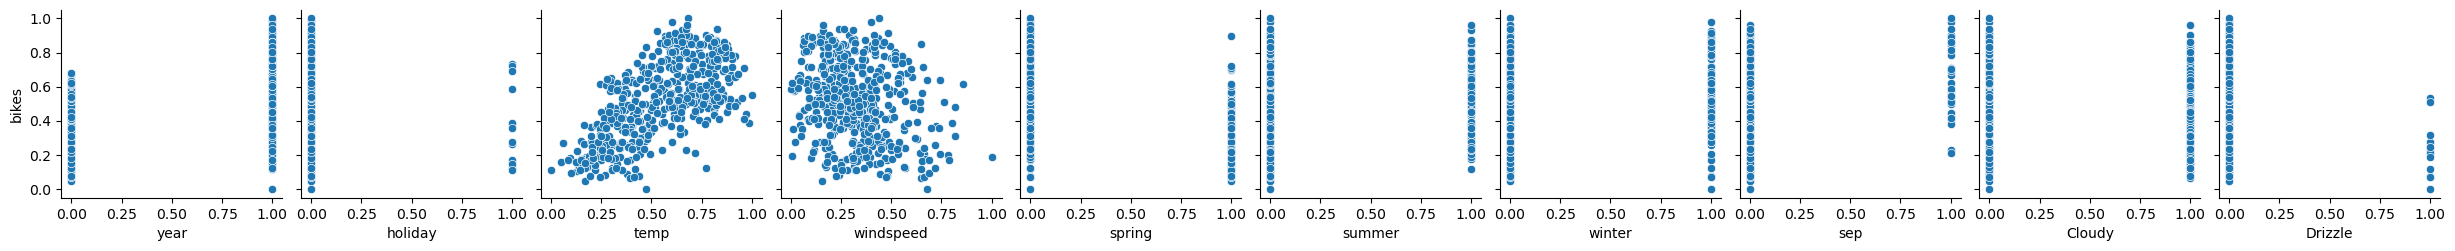

In [122]:
linear_test = X_train_rfe.columns

# Creating a set with the dependent variable and independent variables to check for linearity.

model_params_with_target = pd.concat([bike_train[linear_test], y_train], axis = 1)

# plotting scatter plots between "bikes" and each of the model parameters
sns.pairplot(model_params_with_target, x_vars = model_params_with_target[linear_test], y_vars = "bikes")
plt.show()

    > As we can see in the pair plots, each independent variable has some linear relationship with the dependant one, so this assumption is validated.

#### <font color = Dark> *2. Error terms are normally distributed*

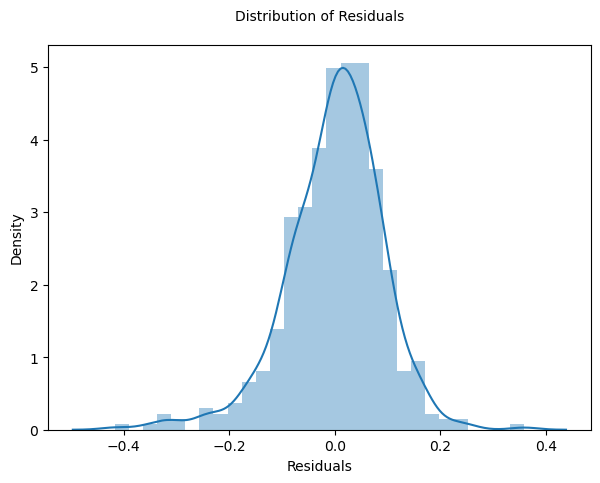

In [126]:
res = y_train - y_train_pred

# plotting dist plot to check the distribution of the residuals

plt.figure(figsize = (7,5))
sns.distplot(res)
plt.title("Distribution of Residuals\n",fontdict={"fontsize": 10, "fontweight": 20, "color": "Black"})
plt.xlabel("Residuals")
plt.show()

    > The error terms are normaly distributed with mean around 0. This assumption is validated

#### <font color = Dark> *3. Error terms are independant of each other*

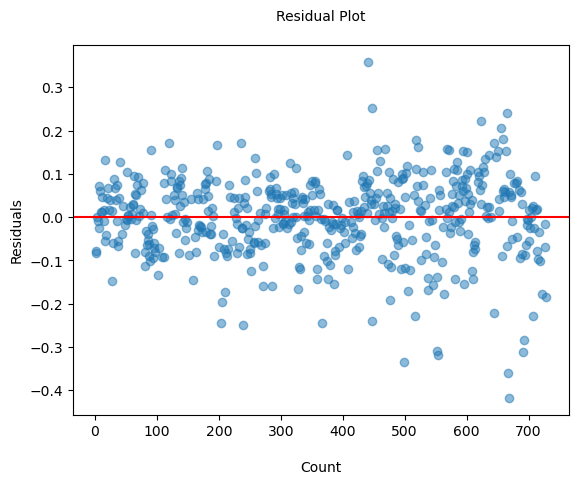

In [129]:
# Plotting the residuals to check for any visible pattern
plt.plot(res,'o', linestyle = '', alpha = 0.5)
plt.axhline(color = "red")
plt.title("Residual Plot\n",fontdict={"fontsize": 10, "fontweight": 20, "color": "Black"})
plt.xlabel("\nCount")
plt.ylabel("Residuals")
plt.show()

    > There is no visible pattern in the residuals. This assumption is validated.

#### <font color = Dark> *4. Error terms have constant variance (Homoscedasticity)*

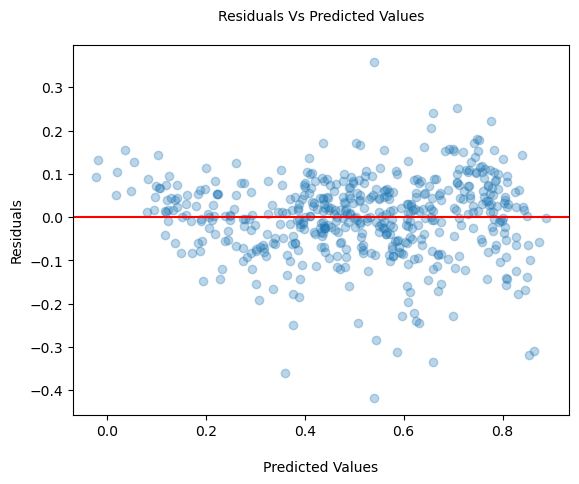

In [132]:
plt.scatter(x = y_train_pred, y = res, alpha = 0.3)
plt.axhline(color = "red")
plt.title("Residuals Vs Predicted Values\n",fontdict={"fontsize": 10, "fontweight": 20, "color": "Black"})
plt.xlabel("\nPredicted Values")
plt.ylabel("Residuals")
plt.show()

    > There is no visible pattern in the residuals vs predicted values. This assumption is validated.

#### <font color = Dark> *5. There is no multicollinearity between the variables*

In [135]:
# VIF re-check
VIF_Calculator(X_train_rfe)

,Features,VIF
3,windspeed,4.60
2,temp,3.84
0,year,2.07
4,spring,1.99
5,summer,1.90
6,winter,1.63
8,Cloudy,1.55
7,sep,1.23
9,Drizzle,1.08
1,holiday,1.04


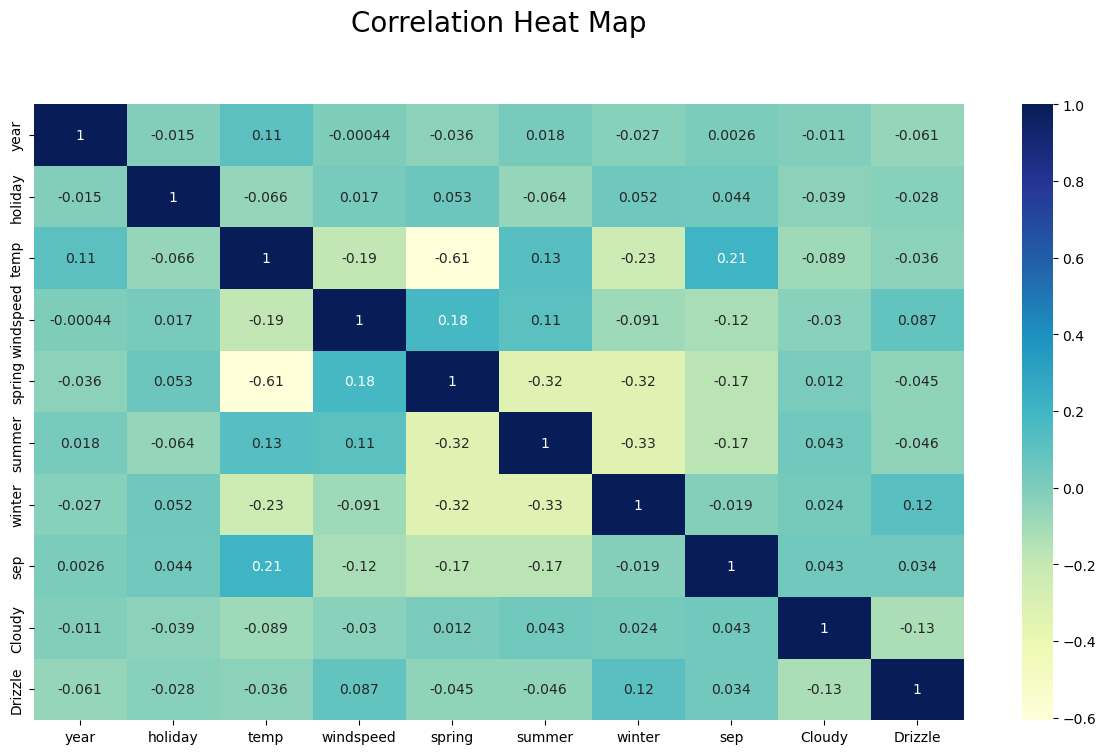

In [136]:
# Corr() heatmap
plt.figure(figsize=(15,8))
sns.heatmap(X_train_rfe.corr(),annot = True, cmap="YlGnBu")
plt.title("Correlation Heat Map\n\n",fontdict={"fontsize": 20, "fontweight": 20, "color": "Black"})
plt.show()

    > As seen above, VIF values for all parameters are below 5 and there is no collniarity between the variables    

    > All the assumptions have been validated, so now we can choose this model as the final one to make the predictions on the test set

## <font color = Dark> *VI. Model Evaluation*

In [141]:
# Scaling the test set
bike_test[numerical_variables] = scaler.transform(bike_test[numerical_variables])

In [142]:
bike_test.head()

,year,holiday,workingday,temp,atemp,humidity,windspeed,bikes,spring,summer,winter,aug,dec,feb,jan,july,june,mar,may,nov,oct,sep,mon,sat,sun,thu,tue,wed,Cloudy,Drizzle
185,0,1,0,0.831783,0.769660,0.657364,0.084219,0.692706,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0
536,1,0,1,0.901354,0.842587,0.610133,0.153728,0.712034,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
300,0,0,0,0.511964,0.496145,0.837699,0.334206,0.303382,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
222,0,0,1,0.881625,0.795343,0.437098,0.339570,0.547400,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
153,0,0,0,0.817246,0.741471,0.314298,0.537414,0.569029,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [143]:
bike_test.describe()

,year,holiday,workingday,temp,atemp,humidity,windspeed,bikes,spring,summer,winter,aug,dec,feb,jan,july,june,mar,may,nov,oct,sep,mon,sat,sun,thu,tue,wed,Cloudy,Drizzle
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,0.481818,0.036364,0.640909,0.558718,0.532847,0.638221,0.313293,0.522154,0.254545,0.263636,0.236364,0.059091,0.086364,0.100000,0.077273,0.104545,0.095455,0.054545,0.086364,0.072727,0.086364,0.086364,0.118182,0.172727,0.154545,0.140909,0.122727,0.159091,0.318182,0.027273
std,0.500809,0.187620,0.480828,0.233187,0.217401,0.148694,0.159584,0.219163,0.436599,0.441609,0.425817,0.236333,0.281541,0.300684,0.267633,0.306665,0.294512,0.227609,0.281541,0.260281,0.281541,0.281541,0.323559,0.378873,0.362295,0.348721,0.328872,0.366595,0.466833,0.163248
min,0.000000,0.000000,0.000000,0.046591,0.025950,0.261915,-0.042808,0.048205,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.355429,0.344870,0.529197,0.198843,0.378595,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.558172,0.544652,0.625590,0.300126,0.524678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.755981,0.713308,0.743798,0.402718,0.677750,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,0.984424,0.980934,1.002146,0.807474,0.963300,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [144]:
# The test set has been scaled in the same was as training set

In [145]:
# Splitting into X_test and y_test
y_test = bike_test.pop("bikes")
X_test = bike_test[linear_test] # Choosing only the model parameters

In [146]:
X_test.head()

,year,holiday,temp,windspeed,spring,summer,winter,sep,Cloudy,Drizzle
185,0,1,0.831783,0.084219,0,0,0,0,1,0
536,1,0,0.901354,0.153728,0,1,0,0,0,0
300,0,0,0.511964,0.334206,0,0,1,0,1,0
222,0,0,0.881625,0.339570,0,0,0,0,0,0
153,0,0,0.817246,0.537414,0,1,0,0,0,0


In [147]:
X_test = sm.add_constant(X_test)

In [148]:
X_test.head()

,const,year,holiday,temp,windspeed,spring,summer,winter,sep,Cloudy,Drizzle
185,1.0,0,1,0.831783,0.084219,0,0,0,0,1,0
536,1.0,1,0,0.901354,0.153728,0,1,0,0,0,0
300,1.0,0,0,0.511964,0.334206,0,0,1,0,1,0
222,1.0,0,0,0.881625,0.339570,0,0,0,0,0,0
153,1.0,0,0,0.817246,0.537414,0,1,0,0,0,0


In [149]:
# Predictions
y_test_pred = model_6.predict(X_test)

In [150]:
r2 = r2_score(y_true = y_test, y_pred = y_test_pred)
print(round(r2, 3))

0.804


In [151]:
# Calculating Adjusted R_square

# Number of observations
N = X_test.shape[0]

# No. of predictors
p = X_test.shape[1]

Adj_r2 = 1 - (((1-r2)*(N - 1))/(N - p -1))

print(round(Adj_r2, 3))

0.793


#### <font color = Dark> *Comparing the results*

-  Train R-Squared: 0.833
-  Train Adjusted R-Squared: 0.829
-  Test R-Squared: 0.804
-  Test Adjusted R-Squared: 0.793

    > The model was able to explain 80.4% of the variance in the test set which is very close to the train set and hence we have a good model to predict the demand for bikes on generalized data. 

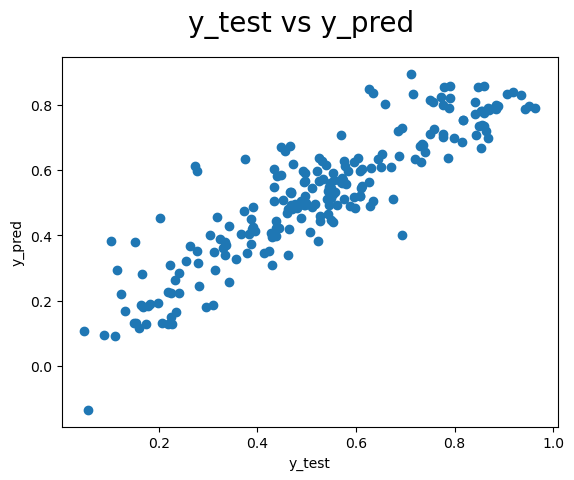

In [156]:
# plotting y_test and y_test_pred to see the spread 

fig = plt.figure()
plt.scatter(y_test, y_test_pred)
fig.suptitle('y_test vs y_pred', fontsize = 20)             
plt.xlabel('y_test')
plt.ylabel('y_pred')    
plt.show()

    > The plot follows a visible diagonal trend indicating the predicted values are generally close to the actual values. Again, by this, we seem to have a good predictor of demand for bikes.

## <font color = Dark> *VII. Model Summary and Suggestions*

In [160]:
model_6.params

const        0.190855
year         0.234132
holiday     -0.096316
temp         0.477737
windspeed   -0.148098
spring      -0.055406
summer       0.062076
winter       0.094476
sep          0.090998
Cloudy      -0.078741
Drizzle     -0.285031
dtype: float64

#### <font color = Dark> *Bike Demand Model and Interpretation*

    > The demand for shared bikes in the USA in a post-covid era can be generally explained by the below equation:

#### <font color = Green> $bikes$ = 0.190855 + (0.477737 * $temp$) + (0.234132 * $year$) + (0.094476 * $winter$) + (0.090998 * $sep$) + (0.062076 * $summer$)
#### <font color = Dark> - (0.285031 * $Drizzle$)- (0.148098 * $windspeed$) - (0.096316 * $holiday$)- (0.078741 * $Cloudy$) - (0.055406 * $spring$)

    > The top 3 variables that predict the demand for shared bikes are temperature, year and drizzle. 
    
    > Year-on-year, the demand tends to increase. 
    
    > Temperature is the biggest influencer in predicting the demand with a coefficient of 0.477, suggesting high temperatures, increase the demand for shared bikes significantly. 
    
    > Drizzle, on the other hand, is interpreted as light snow, light rain + thunderstorm + scattered clouds, and light rain + scattered clouds, which negatively impacts demand with a coefficient of -0.285.

    > Summer and winter seasons along with September month can have a positive impact while cloudy weather, strong winds, spring time and holidays negatively impact the demand for shared bikes. However, the impact of these variables is much less compared to the top-3 mentioned above.

#### <font color = Dark> *Suggestions*

    > BoomBikes can focus on increasing their supply of bike docks in regions of the USA where temperatures are generally high, have long summers and long winters, clear weather for most of the year and get low rainfall. These regions will help maximise the impact of factors that positively affect the demand for shared bikes. 

    > They can also focus on areas within these regions where people tend to go to work often like tech parks, corporate offices, Govt. establishments, etc.

    > Also, during the holidays, they can experiment with offers and try new ways of marketing their service to fit that holiday period so that the dip in demand is softened. 

    > Focusing on establishing a brand that depicts all the characteristics of people who tend to live in such regions will also help them in retention and gaining a sense of reliability.

-------